<a href="https://colab.research.google.com/github/2403a52029-lab/ML_Assignments/blob/main/ML_LAB_11_2403A52029_B_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [2]:
# Load Breast Cancer dataset
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

# Convert to DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Show first rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Target labels (0 = malignant, 1 = benign)
y.value_counts()

,count
1,357
0,212


In [4]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (455, 30)
Testing size: (114, 30)


In [5]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

# ROC AUC
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree Accuracy: 0.9473684210526315
Decision Tree ROC-AUC: 0.9439895185063871


In [6]:
# Train AdaBoost model
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

ada_model.fit(X_train, y_train)

# Predictions
ada_pred = ada_model.predict(X_test)

# Accuracy
ada_accuracy = accuracy_score(y_test, ada_pred)

# ROC AUC
ada_auc = roc_auc_score(y_test, ada_model.predict_proba(X_test)[:,1])

print("AdaBoost Accuracy:", ada_accuracy)
print("AdaBoost ROC-AUC:", ada_auc)

AdaBoost Accuracy: 0.9649122807017544
AdaBoost ROC-AUC: 0.9924664264657713


In [7]:
print("Model Comparison")
print("----------------------")

print("Decision Tree Accuracy :", dt_accuracy)
print("AdaBoost Accuracy      :", ada_accuracy)

print("Decision Tree ROC-AUC  :", dt_auc)
print("AdaBoost ROC-AUC       :", ada_auc)

Model Comparison
----------------------
Decision Tree Accuracy : 0.9473684210526315
AdaBoost Accuracy      : 0.9649122807017544
Decision Tree ROC-AUC  : 0.9439895185063871
AdaBoost ROC-AUC       : 0.9924664264657713


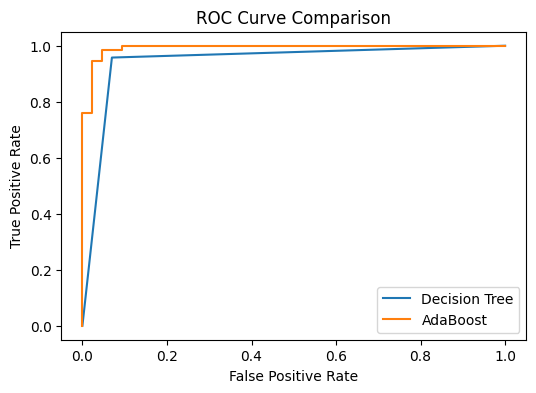

In [8]:
# ROC curve for Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_model.predict_proba(X_test)[:,1])

# ROC curve for AdaBoost
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(6,4))

plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(ada_fpr, ada_tpr, label="AdaBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()